In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc
rc('animation', html='html5')
import os

import pandas as pd
import matplotlib.dates as mdates

In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [5]:
path_run = '/data/jvalenti/results/' 
#path_run = '/home/jvalenti/projects/rrg-allen/SalishSea/nowcast-green.202111/'
day = 1
start = datetime(2023,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'02jan23/SHEM_1h_20230102-20230102_biol_T.nc'

In [6]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [7]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


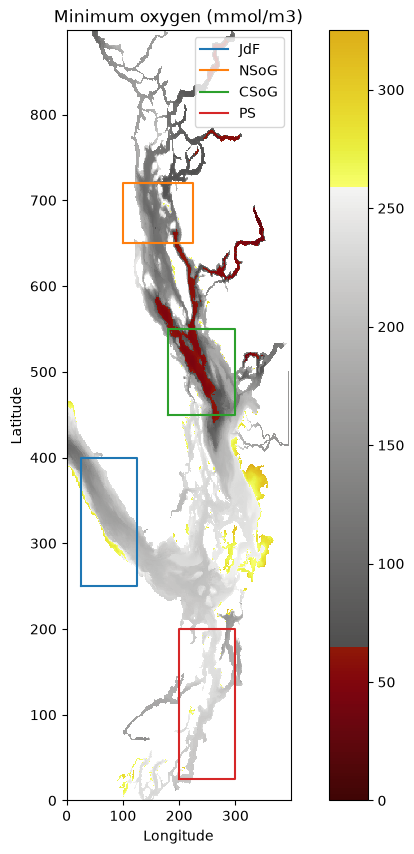

In [8]:
cmap = cmocean.cm.oxy
colors=['tab:blue','tab:orange','tab:green','tab:red']
fig, ax = plt.subplots(figsize=(10,10))
ox_0 = Ox[0,:,:,:]*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')
plt.pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [9]:
def domain_profile(
    hbac,
    mask,
    colors,
    region=None,
    regions=None,
    plot=True,
    daily_mean=False
):
    """Compute volume-weighted mean + std vertical profile optionally for a sub-region."""

    # volume mask
    volume = mask.volume
    vol = volume.where(mask.tmask == 1)

    # region slicing
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        hbac_r = hbac.isel(y=slice(y0, y1), x=slice(x0, x1))
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        hbac_r = hbac
        vol_r = vol

    # daily mean 
    if daily_mean:
        hbac_day = hbac_r.mean(dim="time_counter", skipna=True) 
    else:
        hbac_day = hbac_r
    #mean profile 
    hbac_total = (hbac_day * vol_r).sum(("z", "y", "x"))
    vol_sum = vol_r.sum(("z", "y", "x"))
    hbac_vmean = hbac_total / vol_sum

    # plot
    if plot:
        y = hbac_day.deptht.values.ravel()
        mean = hbac_vmean.values.ravel()
        plt.plot(mean, y, label=region,c=colors[region])
        plt.legend()

    return hbac_vmean

In [10]:
def progress_bar(iterable, total=None, length=30):
    total = total or len(iterable)
    for i, item in enumerate(iterable, 1):
        filled = int(length * i / total)
        bar = '█' * filled + '-' * (length - filled)
        print(f'\r|{bar}| {i}/{total}', end='', flush=True)
        yield item
    print()

In [11]:
# path_run = '/data/jvalenti/results/' 
# day = 0
# Len = 1096
# start = datetime(2023,1,1)

# mean_profiles = np.full((2,len(regions.keys()), Len, Ox.deptht.shape[0]),np.nan)

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         T = ds.microzooplankto_Z1.isel(time_counter=0)
#         S = ds.mesozooplankton_Z2.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[0, i, day, :]  = domain_profile(T, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
#             mean_profiles[1, i, day, :]  = domain_profile(S, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_zoo_regions.npy', mean_profiles)

In [16]:
# path_run = '/results2/SalishSea/nowcast-green.202111/'
# day = 0
# Len = 1096
# start = datetime(2023,1,1)

# mean_profiles = np.full((2,len(regions.keys()), Len, Ox.deptht.shape[0]),np.nan)

# for day in progress_bar(range(Len)):
#     with xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')) as ds:
#         T = ds.microzooplankton.isel(time_counter=0)
#         S = ds.mesozooplankton.isel(time_counter=0)
#         for i,region in enumerate(regions.keys()):
#             mean_profiles[0, i, day, :]  = domain_profile(T, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
#             mean_profiles[1, i, day, :]  = domain_profile(S, mask,colors_reg, region=region, regions=regions, plot=False).values.ravel()
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles2021_zoo_regions.npy', mean_profiles)

In [17]:
Zoo = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_zoo_regions.npy')
Zoo_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles2021_zoo_regions.npy')
Zoo_2024 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_oxy_zoo_regions.npy')

In [18]:
Z1 = Zoo[0,:,:,:]#np.append(Zoo[0, :,:424, :], Zoo[0, :, 425:, :], axis=1)
Z2 = Zoo[1,:,:,:]#np.append(Zoo[1, :,:424, :], Zoo[1, :, 425:, :], axis=1)

Z1_21 = Zoo_2021[0,:,:,:]#np.append(Zoo_2021[0, :,:424, :], Zoo_2021[0, :, 425:, :], axis=1)
Z2_21 = Zoo_2021[1,:,:,:]#np.append(Zoo_2021[1, :,:424, :], Zoo_2021[1, :, 425:, :], axis=1)

# Z1_24 = np.append(Zoo_2024[0, :,:424, :], Zoo_2024[0, :, 425:, :], axis=1)
# Z2_24 = np.append(Zoo_2024[1, :,:424, :], Zoo_2024[1, :, 425:, :], axis=1)

In [19]:
Z1 = np.where(Z1==0, np.nan, Z1)
Z2 = np.where(Z2==0, np.nan, Z2)
Z1_21 = np.where(Z1_21==0, np.nan, Z1_21)
Z2_21 = np.where(Z2_21==0, np.nan, Z2_21)
# Z1_24 = np.where(Z1_24==0, np.nan, Z1_24)
# Z2_24 = np.where(Z2_24==0, np.nan, Z2_24)


Z1diff = (Z1 - Z1_21)/Z1_21
Z2diff = (Z2 - Z2_21)/Z2_21

# Z1diff_24 = (Z1 - Z1_24)/Z1_24
# Z2diff_24 = (Z2 - Z2_24)/Z2_24  

In [20]:
colors_reg_winter = {'JdF':'#87CEEB','NSoG':"#F7D699",'CSoG':'#90EE90','PS':'#FFC0CB'}
colors_reg={'JdF':'#3054FC','NSoG':'#FFA500','CSoG':'#008000','PS':'#FF0000'}

Text(0.02, 0.5, 'Depth (m)')

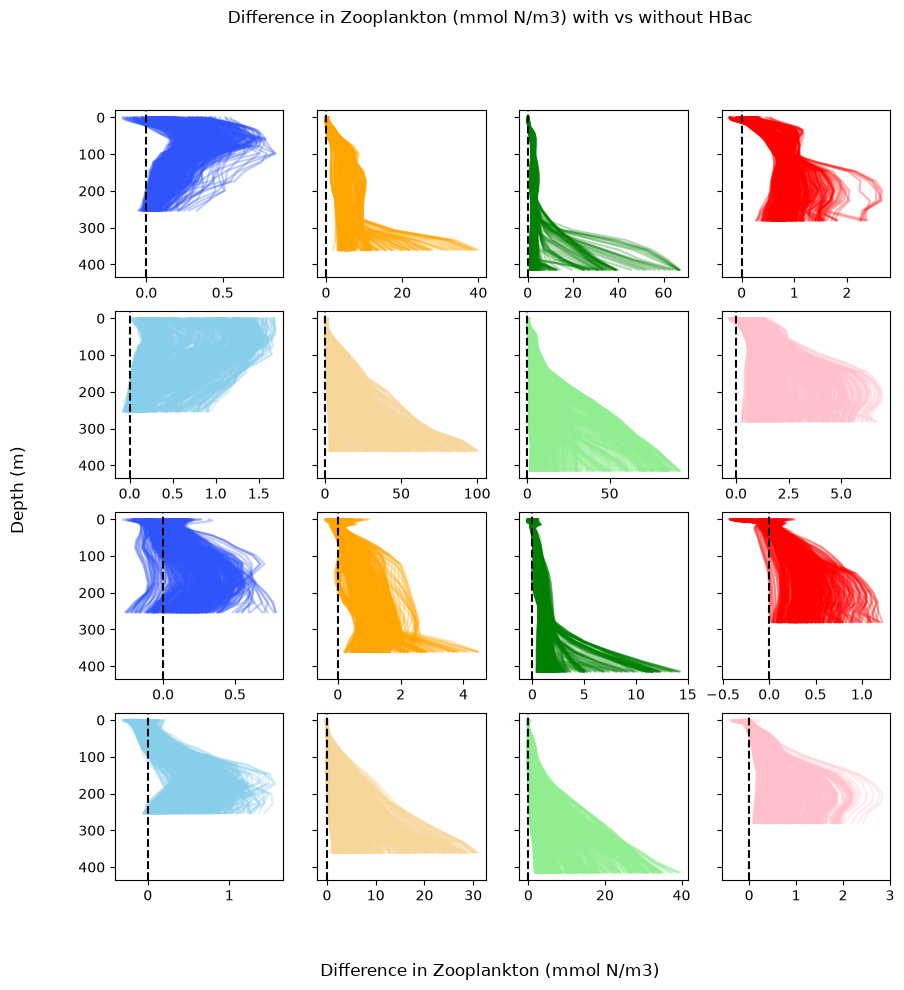

In [23]:
summer = np.r_[121:274, 486:639,852:1005]
winter = np.ones(1096, dtype=bool)
winter[summer] = False


fig, axs = plt.subplots(4,len(colors_reg), figsize=(10,10),sharey=True)
axs = axs.flatten()
for i, region in enumerate(colors_reg.keys()):
    axs[i].plot(Z1diff[i,summer,:].T,mask.gdept_1d[0,:],color=colors_reg[region],alpha=0.3)
    axs[4+i].plot(Z1diff[i,winter,:].T,mask.gdept_1d[0,:],color=colors_reg_winter[region],alpha=0.3)  
    axs[i].axvline(0, color='k', linestyle='--')
    axs[4+i].axvline(0, color='k', linestyle='--')

for i, region in enumerate(colors_reg.keys()):
    axs[8+i].plot(Z2diff[i,summer,:].T,mask.gdept_1d[0,:],color=colors_reg[region],alpha=0.3)
    axs[12+i].plot(Z2diff[i,winter,:].T,mask.gdept_1d[0,:],color=colors_reg_winter[region],alpha=0.3)
    axs[8+i].axvline(0, color='k', linestyle='--')
    axs[12+i].axvline(0, color='k', linestyle='--')



ax = plt.gca()
ax.invert_yaxis()
plt.suptitle('Difference in Zooplankton (mmol N/m3) with vs without HBac')
fig.supxlabel('Difference in Zooplankton (mmol N/m3)')
fig.supylabel('Depth (m)')



In [24]:
vol = mask.volume.where(mask.tmask == 1).sel(t=0)

In [25]:
def weighted_mean_concentration(mean_profile,region=None,regions=None,zmax=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1))
    else:
        region = 'full domain'
        vol_r = vol

    vol_r = vol_r.sum(axis=(1,2))
    vol_r = np.array(vol_r)
    mask = (np.isfinite(mean_profile))&(mean_profile!=0)
    
    if zmax is not None:
        weighted_mean = np.nansum(mean_profile[:,:zmax] * vol_r[:zmax], axis=1) / np.nansum(mask[:,:zmax]*vol_r[:zmax],axis=1)    
    else: 
        weighted_mean = np.nansum(mean_profile * vol_r, axis=1) / np.nansum(mask*vol_r,axis=1)

    return weighted_mean

In [26]:
Len = Z1diff.shape[1]
z11 = np.full((len(regions.keys())+1,Len), np.nan)
#z12 = np.full((len(regions.keys())+1,Len), np.nan)
z21 = np.full((len(regions.keys())+1,Len), np.nan)
#z22 = np.full((len(regions.keys())+1,Len), np.nan)

for ii, region in enumerate(regions.keys()):
    z11[ii,:] = weighted_mean_concentration(Z1diff[ii,:,:], region=region, regions=regions)
    #z12[ii,:] = weighted_mean_concentration(Z1diff_24[ii,:,:], region=region, regions=regions)
    z21[ii,:] = weighted_mean_concentration(Z2diff[ii,:,:], region=region, regions=regions)
    #z22[ii,:] = weighted_mean_concentration(Z2diff_24[ii,:,:], region=region, regions=regions)

Text(0.5, 0.98, 'Difference in Zooplankton integrated water column')

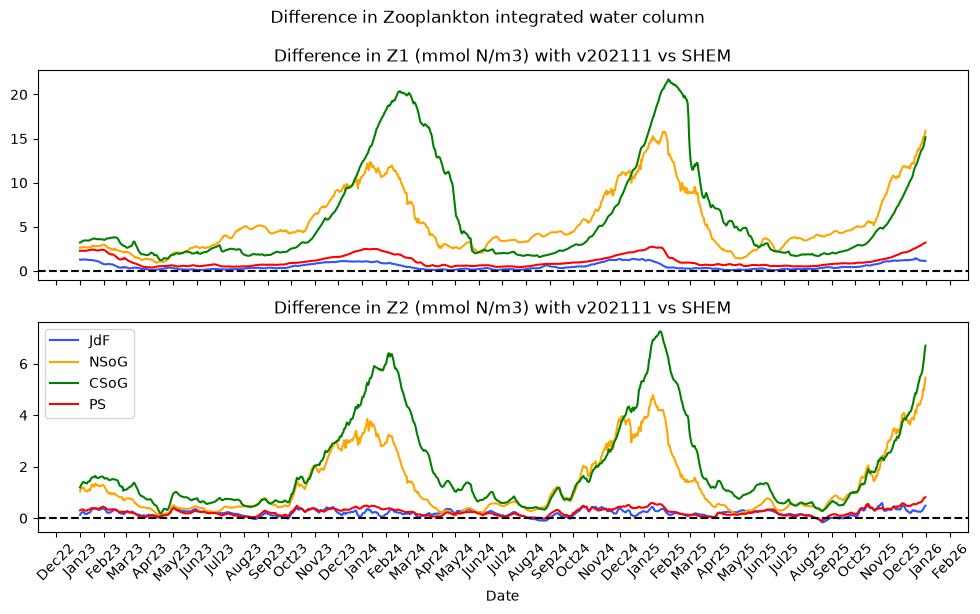

In [32]:
fig,axs = plt.subplots(2,1,figsize=(12,6),sharex=True)
time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')

for ii, region in enumerate(regions.keys()):
    axs[0].plot(time,z11[ii,:].T,c=colors_reg[region],label=region)
    #axs[1].plot(time,z12[ii,:].T,c=colors_reg[region],label=region)
    axs[1].plot(time,z21[ii,:].T,c=colors_reg[region],label=region)
    #axs[3].plot(time,z22[ii,:].T,c=colors_reg[region],label=region)
plt.legend()
plt.xlabel('Days')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
axs[0].set_title('Difference in Z1 (mmol N/m3) with v202111 vs SHEM')
#axs[1].set_title('Difference in Z1 (mmol N/m3) with v202410 vs SHEM')
axs[1].set_title('Difference in Z2 (mmol N/m3) with v202111 vs SHEM')
#axs[3].set_title('Difference in Z2 (mmol N/m3) with v202410 vs SHEM')
axs[0].axhline(y=0, color='black', linestyle='--')
axs[1].axhline(y=0, color='black', linestyle='--')
plt.xlabel('Date')
plt.suptitle('Difference in Zooplankton integrated water column')

In [35]:
Len = Z1diff.shape[1]
z11 = np.full((len(regions.keys())+1,Len), np.nan)
#z12 = np.full((len(regions.keys())+1,Len), np.nan)
z21 = np.full((len(regions.keys())+1,Len), np.nan)
#z22 = np.full((len(regions.keys())+1,Len), np.nan)

for ii, region in enumerate(regions.keys()):
    z11[ii,:] = weighted_mean_concentration(Z1diff[ii,:,:], region=region, regions=regions,zmax = 10)
    #z12[ii,:] = weighted_mean_concentration(Z1diff_24[ii,:,:], region=region, regions=regions,zmax = 10)
    z21[ii,:] = weighted_mean_concentration(Z2diff[ii,:,:], region=region, regions=regions,zmax = 10)
    #z22[ii,:] = weighted_mean_concentration(Z2diff_24[ii,:,:], region=region, regions=regions,zmax = 10)

Text(0.5, 0.98, 'Difference in Zooplankton integrated top 10 m')

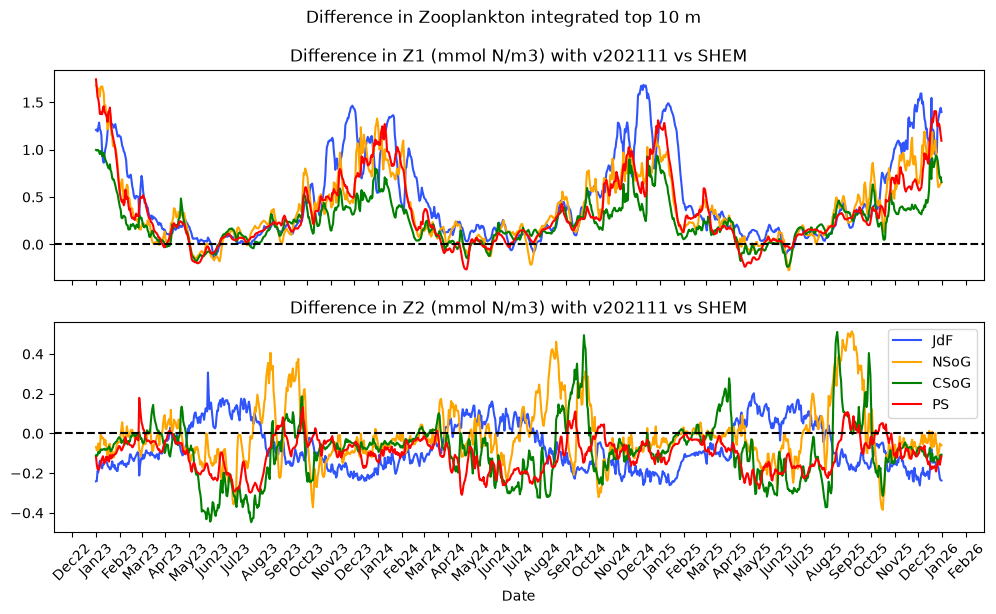

In [36]:
fig,axs = plt.subplots(2,1,figsize=(12,6),sharex=True)
time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')

for ii, region in enumerate(regions.keys()):
    axs[0].plot(time,z11[ii,:].T,c=colors_reg[region],label=region)
    #axs[1].plot(time,z12[ii,:].T,c=colors_reg[region],label=region)
    axs[1].plot(time,z21[ii,:].T,c=colors_reg[region],label=region)
    #axs[3].plot(time,z22[ii,:].T,c=colors_reg[region],label=region)
plt.legend()
plt.xlabel('Days')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
axs[0].set_title('Difference in Z1 (mmol N/m3) with v202111 vs SHEM')
#axs[1].set_title('Difference in Z1 (mmol N/m3) with v202410 vs SHEM')
axs[1].set_title('Difference in Z2 (mmol N/m3) with v202111 vs SHEM')
#axs[3].set_title('Difference in Z2 (mmol N/m3) with v202410 vs SHEM')
axs[0].axhline(y=0, color='black', linestyle='--')
axs[1].axhline(y=0, color='black', linestyle='--')

plt.xlabel('Date')
plt.suptitle('Difference in Zooplankton integrated top 10 m')

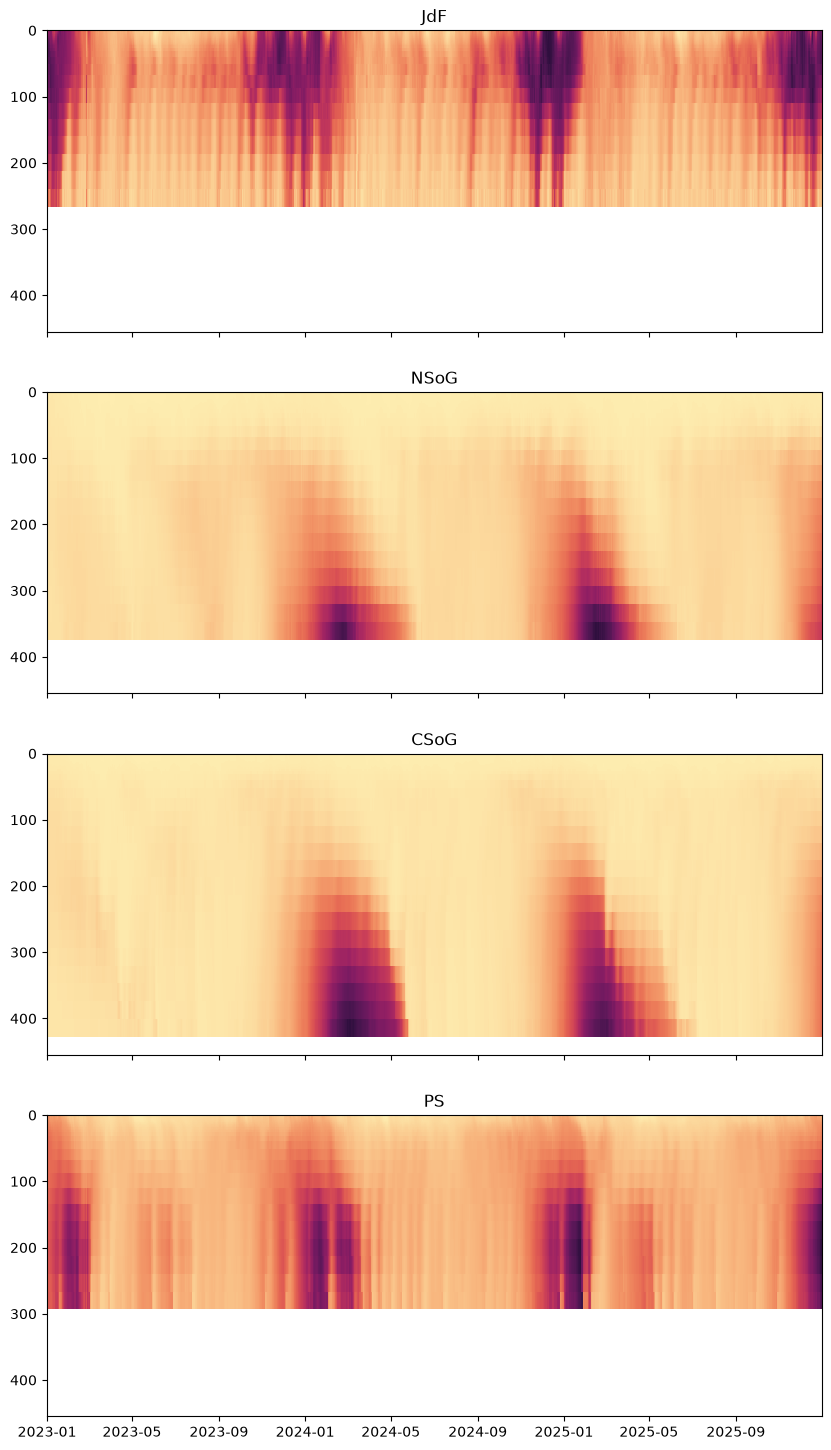

In [38]:
fig,axs = plt.subplots(4,1,figsize=(10,18),sharex=True)
time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')
for ii, region in enumerate(regions.keys()):
    axs[ii].pcolormesh(time, mask.gdept_0[0,:,0,0],Z1diff[ii,:,:].T,cmap=cmocean.cm.matter)
    axs[ii].invert_yaxis()
    axs[ii].set_title(region)